# **Para ver los ejemplos de tabla que te he puesto clica en las celdas de texto**

Para aberiguar la temperatura del aula 2 establecimos que habia que hacer una regresion lineal, como esto fue imposible por la falta de datos decidimos hacer una correcion del sesgo.

Usamos como datos del aula 1 el csv (resultado_final) el cual es una cop8ia tal cual de los datos del sql descargar sin limpiar ni nada, y los datos del aula 2 en el csv (History).

Lo que hacemos es como history solo tien temperaturas de un periodo reducido de tiempo y resultado final tiene un monton, comparamos las temperaturas que coincidan en el tiempo en los dos csv y al tener una diferencia comprobada extrapolamos las demas temperaturas de las demas fechas.

ej:

History                             resultado_final
2025/09/01     27º                  2025/09/01     29º        
2025/09/03     20º                  2025/09/03     22º
2025/09/04     21º                  2025/09/04     23º
2025/09/05     22º                  2025/09/05     24º
2025/09/06     23º                  2025/09/06     25º
2025/09/07     20º                  2025/09/07     22º

diferencia 2 º


History                             resultado_final         History extrapolado
2025/08/01     X                  2025/08/01     29º        2025/08/01     27º
2025/08/03     X                  2025/08/03     22º        2025/08/01     20º
2025/08/04     X                  2025/08/04     23º        2025/08/01     21º
2025/08/05     X                  2025/08/05     24º        2025/08/01     22º
2025/08/06     X                  2025/08/06     25º        2025/08/01     23º
2025/08/07     X                  2025/08/07     22º        2025/08/01     20º

In [2]:
import pandas as pd
import numpy as np

# 1. CARGA
df_ref = pd.read_csv('/content/resultado_final.csv', low_memory=False)
hist = pd.read_csv('/content/History_2025-09-01_100-2026-03-02_1400.csv')

# 2. PROCESAR AULA 1 (Referencia) - FILTRO ULTRA ESTRICTO
df_ref['state'] = pd.to_numeric(df_ref['state'], errors='coerce')
df_ref['datetime'] = pd.to_datetime(df_ref['time'], format='mixed').dt.floor('h')

# SOLO sensores que son de temperatura ambiental, NO presión, NO humedad, NO electrónicos
sensores_validos = [
    'sensor.sensor_temperatura_1_temperature',
    'sensor.sensor_temperatura_2_temperature',
    'sensor.sensor_temperatura_3_temperature',
    'sensor.sensor_temperatura_4_temperature',
    'sensor.sensor_temperatura_3_nuevo_4_temperature'
]

# Filtramos solo esos sensores y eliminamos valores imposibles (ruido)
df_aula1_clean = df_ref[df_ref['entity_id'].isin(sensores_validos)].copy()
df_aula1_clean = df_aula1_clean[(df_aula1_clean['state'] > 0) & (df_aula1_clean['state'] < 50)]

df_aula1 = df_aula1_clean.groupby('datetime')['state'].mean().to_frame()
df_aula1.columns = ['temp_aula1']

# 3. PROCESAR AULA 2 (History)
hist['datetime'] = pd.to_datetime(hist['date'].str.replace('.', '-') + ' ' + hist['time'])
hist['temp_aula2'] = pd.to_numeric(hist['temperature ℃'], errors='coerce')
df_aula2 = hist.set_index('datetime')[['temp_aula2']].resample('h').mean()

# 4. UNIÓN Y CÁLCULO DE DIFERENCIA REAL
df_comparacion = pd.merge(df_aula1, df_aula2, left_index=True, right_index=True, how='inner').dropna()

if len(df_comparacion) > 0:
    diferencia_real = (df_comparacion['temp_aula2'] - df_comparacion['temp_aula1']).mean()
    print(f"✅ ¡Diferencia lógica encontrada! El Aula 2 está a {diferencia_real:.2f}°C del Aula 1.")
else:
    diferencia_real = 0.0
    print("⚠️ No se encontró solape. Usando diferencia de 0°C.")

# 5. EXTRAPOLACIÓN
df_final = pd.merge(df_aula1, df_aula2, left_index=True, right_index=True, how='outer')
df_final['temp_aula2_completada'] = df_final['temp_aula2'].fillna(df_final['temp_aula1'] + diferencia_real)

# 6. GUARDAR
df_final = df_final.dropna(subset=['temp_aula1']) # Solo horas donde el Aula 1 trabajó
df_final.to_csv('aula2_limpio_FINAL.csv')

print("🚀 Proceso terminado. Revisa los primeros valores abajo:")
df_final[['temp_aula1', 'temp_aula2', 'temp_aula2_completada']].head(15)

✅ ¡Diferencia lógica encontrada! El Aula 2 está a 1.41°C del Aula 1.
🚀 Proceso terminado. Revisa los primeros valores abajo:


,temp_aula1,temp_aula2,temp_aula2_completada
datetime,,,
2024-12-10 19:00:00,21.150000,NaN,22.556923
2024-12-10 20:00:00,21.166000,NaN,22.572923
2024-12-10 21:00:00,20.474286,NaN,21.881209
2024-12-10 22:00:00,19.646000,NaN,21.052923
2024-12-10 23:00:00,19.353333,NaN,20.760257
2024-12-11 00:00:00,19.173333,NaN,20.580257
2024-12-11 01:00:00,18.952500,NaN,20.359423
2024-12-11 02:00:00,18.613333,NaN,20.020257
2024-12-11 03:00:00,18.530000,NaN,19.936923


Comprobacion poara ver si ha dado todas las filas o solo habia generado unas pocas

In [3]:
# Ver el final del archivo (donde deberían estar los datos de 2026)
print("Últimos datos del archivo:")
display(df_final.tail(15))

# Ver una muestra aleatoria de todo el periodo
print("Muestra aleatoria de diferentes fechas:")
display(df_final.sample(15))

# Comprobar el rango total de fechas que tiene el archivo
print(f"El archivo empieza en: {df_final.index.min()}")
print(f"El archivo termina en: {df_final.index.max()}")

Últimos datos del archivo:


,temp_aula1,temp_aula2,temp_aula2_completada
datetime,,,
2026-03-01 19:00:00,18.842000,20.6,20.6
2026-03-01 20:00:00,18.692000,20.5,20.5
2026-03-01 21:00:00,18.787143,20.5,20.5
2026-03-01 22:00:00,18.795556,20.5,20.5
2026-03-01 23:00:00,18.712857,20.4,20.4
2026-03-02 00:00:00,18.652222,20.4,20.4
2026-03-02 01:00:00,18.573846,20.3,20.3
2026-03-02 02:00:00,18.490000,20.3,20.3
2026-03-02 03:00:00,18.487647,20.3,20.3


Muestra aleatoria de diferentes fechas:


,temp_aula1,temp_aula2,temp_aula2_completada
datetime,,,
2025-02-20 06:00:00,20.096000,NaN,21.502923
2025-02-15 09:00:00,19.356667,NaN,20.763590
2025-10-01 01:00:00,23.925000,25.2,25.200000
2024-12-20 00:00:00,19.765000,NaN,21.171923
2025-04-06 04:00:00,20.360000,NaN,21.766923
2025-02-12 20:00:00,21.475833,NaN,22.882757
2025-06-21 08:00:00,29.196250,NaN,30.603173
2025-05-09 12:00:00,23.415000,NaN,24.821923
2025-10-06 22:00:00,24.436667,25.5,25.500000


El archivo empieza en: 2024-12-10 19:00:00
El archivo termina en: 2026-03-02 09:00:00


Codigo para visualizar en un grafico los datos de temperatura extraidos con la correccion del sesgo

✅ Archivo 'comparativa_final_aula1_aula2.csv' creado con éxito.


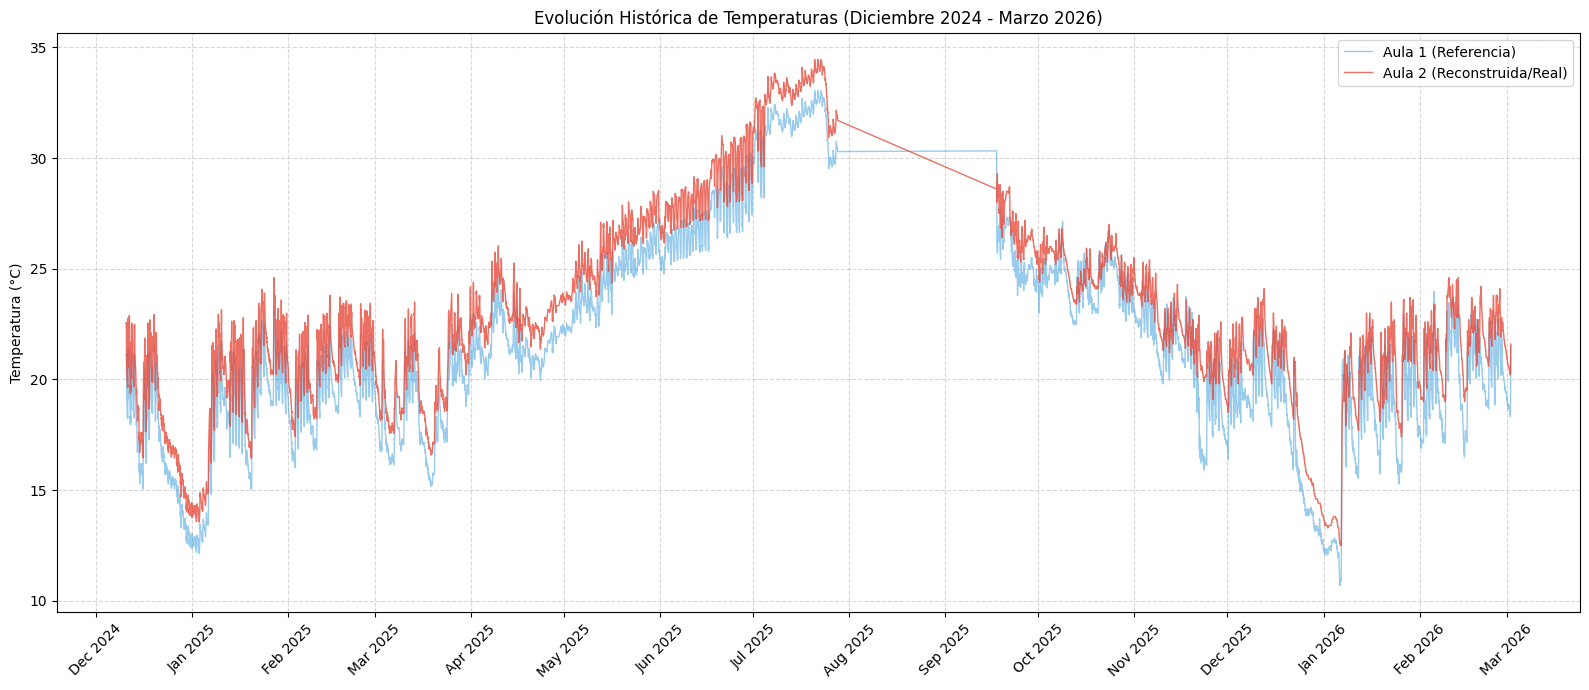


Registros por año encontrados:
datetime
2024     509
2025    7474
2026    1450
Name: count, dtype: int64


In [4]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- TAREA 1: GENERAR EL CSV FINAL ---
# Creamos un dataframe limpio con las columnas que nos interesan
df_export = df_final[['temp_aula1', 'temp_aula2', 'temp_aula2_completada']].copy()

# Resetear el índice para que la fecha sea una columna normal
df_export = df_export.reset_index()
df_export.rename(columns={'index': 'fecha_hora'}, inplace=True)

# Guardar el nuevo CSV
nombre_archivo = 'comparativa_final_aula1_aula2.csv'
df_export.to_csv(nombre_archivo, index=False)

print(f"✅ Archivo '{nombre_archivo}' creado con éxito.")

# --- TAREA 2: GRÁFICO DE TODA LA LÍNEA DE TIEMPO ---
plt.figure(figsize=(16, 7))

# Dibujamos la media del Aula 1
plt.plot(df_final.index, df_final['temp_aula1'],
         label='Aula 1 (Referencia)', color='#3498db', alpha=0.5, linewidth=1)

# Dibujamos la temperatura completada del Aula 2
plt.plot(df_final.index, df_final['temp_aula2_completada'],
         label='Aula 2 (Reconstruida/Real)', color='#e74c3c', alpha=0.8, linewidth=1)

# Formatear el eje X para que muestre meses y años
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)

plt.title('Evolución Histórica de Temperaturas (Diciembre 2024 - Marzo 2026)')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

# Resumen de datos por año para tu tranquilidad
print("\nRegistros por año encontrados:")
print(df_final.index.year.value_counts().sort_index())



In [5]:
from google.colab import files

# Esto forzará al navegador a descargar el archivo directamente
files.download('comparativa_final_aula1_aula2.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Humedad**

Como en los dos csvs tambien habia humedad decidimos hacer tambien la extrapolacion con las humedades para tener mas datos en caso de que fuese necesario

In [6]:
import pandas as pd
import numpy as np

# 1. CARGA
df_ref = pd.read_csv('/content/resultado_final.csv', low_memory=False)
hist = pd.read_csv('/content/History_2025-09-01_100-2026-03-02_1400.csv')

# 2. PROCESAR AULA 1 (Referencia) - HUMEDAD
df_ref['state'] = pd.to_numeric(df_ref['state'], errors='coerce')
df_ref['datetime'] = pd.to_datetime(df_ref['time'], format='mixed').dt.floor('h')

# Buscamos sensores de humedad ambiental (filtramos 'device' para evitar ruido)
sensores_hum_validos = [col for col in df_ref['entity_id'].unique()
                        if 'humidity' in col and 'device' not in col]

print(f"Sensores de Humedad detectados en Aula 1: {sensores_hum_validos}")

# Filtramos y limpiamos valores imposibles (0% a 100%)
df_aula1_hum = df_ref[df_ref['entity_id'].isin(sensores_hum_validos)].copy()
df_aula1_hum = df_aula1_hum[(df_aula1_hum['state'] >= 0) & (df_aula1_hum['state'] <= 100)]

df_aula1_h = df_aula1_hum.groupby('datetime')['state'].mean().to_frame()
df_aula1_h.columns = ['hum_aula1']

# 3. PROCESAR AULA 2 (History - Humedad)
hist['datetime'] = pd.to_datetime(hist['date'].str.replace('.', '-') + ' ' + hist['time'])
# Nota: En tu History la columna suele llamarse 'humidity %RH'
hist['hum_aula2'] = pd.to_numeric(hist['humidity %RH'], errors='coerce')
df_aula2_h = hist.set_index('datetime')[['hum_aula2']].resample('h').mean()

# 4. UNIÓN Y CÁLCULO DE DIFERENCIA (BIAS)
df_comp_h = pd.merge(df_aula1_h, df_aula2_h, left_index=True, right_index=True, how='inner').dropna()

if len(df_comp_h) > 0:
    diff_hum = (df_comp_h['hum_aula2'] - df_comp_h['hum_aula1']).mean()
    print(f"✅ ¡Diferencia encontrada! El Aula 2 tiene un {diff_hum:.2f}% de humedad extra respecto al Aula 1.")
else:
    diff_hum = 0.0
    print("⚠️ No se encontró solape para humedad. Usando diferencia de 0%.")

# 5. EXTRAPOLACIÓN
df_final_h = pd.merge(df_aula1_h, df_aula2_h, left_index=True, right_index=True, how='outer')
df_final_h['hum_aula2_completada'] = df_final_h['hum_aula2'].fillna(df_final_h['hum_aula1'] + diff_hum)

# Aseguramos que la humedad no se salga del rango 0-100 por el ajuste
df_final_h['hum_aula2_completada'] = df_final_h['hum_aula2_completada'].clip(0, 100)

# 6. GUARDAR
df_final_h.to_csv('humedad_aula2_reconstruida.csv')
print("🚀 Archivo 'humedad_aula2_reconstruida.csv' generado con éxito.")

# Mostrar muestra
df_final_h[['hum_aula1', 'hum_aula2', 'hum_aula2_completada']].head(10)

Sensores de Humedad detectados en Aula 1: ['sensor.sensor_temperatura_1_humidity', 'sensor.0x00158d000ae1b025_humidity', 'sensor.sensor_temperatura_22_humidity', 'sensor.sensor_temperatura_2_humidity', 'sensor.manises_valencia_humidity', 'sensor.manises_valencia_daily_max_humidity', 'sensor.manises_valencia_daily_min_humidity', 'sensor.0x00158d000ae469dd_humidity', 'sensor.sensor_temperatura_3_humidity', 'sensor.0x00158d000ad80141_humidity', 'sensor.sensor_temperatura_4_humidity', 'sensor.sensor_temperatura_3_nuevo_4_humidity']
✅ ¡Diferencia encontrada! El Aula 2 tiene un -1.21% de humedad extra respecto al Aula 1.
🚀 Archivo 'humedad_aula2_reconstruida.csv' generado con éxito.


,hum_aula1,hum_aula2,hum_aula2_completada
datetime,,,
2024-12-10 19:00:00,46.720000,NaN,45.510221
2024-12-10 20:00:00,53.728333,NaN,52.518554
2024-12-10 21:00:00,52.526667,NaN,51.316887
2024-12-10 22:00:00,51.407143,NaN,50.197363
2024-12-10 23:00:00,53.930000,NaN,52.720221
2024-12-11 00:00:00,68.890000,NaN,67.680221
2024-12-11 01:00:00,67.195000,NaN,65.985221
2024-12-11 02:00:00,66.560000,NaN,65.350221
2024-12-11 03:00:00,53.026000,NaN,51.816221


Codigo para visualizar en un grafico los datos de la humedad extraidos con la correccion del sesgo

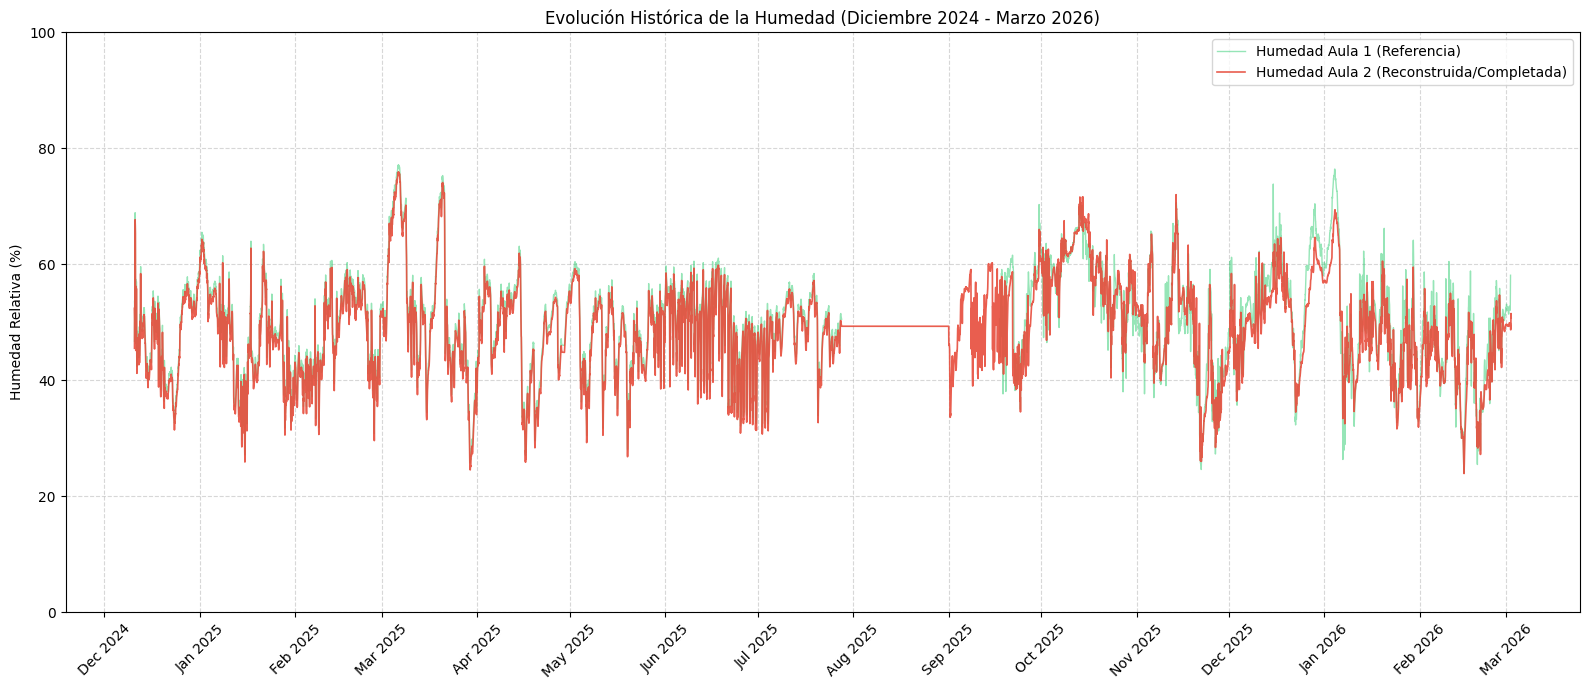

In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Configurar el tamaño y estilo del gráfico
plt.figure(figsize=(16, 7))

# 2. Dibujar la humedad del Aula 1 (Referencia) - Usamos un verde suave
plt.plot(df_final_h.index, df_final_h['hum_aula1'],
         label='Humedad Aula 1 (Referencia)', color='#2ecc71', alpha=0.5, linewidth=1)

# 3. Dibujar la humedad reconstruida del Aula 2 - AHORA EN ROJO
plt.plot(df_final_h.index, df_final_h['hum_aula2_completada'],
         label='Humedad Aula 2 (Reconstruida/Completada)', color='#e74c3c', alpha=0.9, linewidth=1.2)

# 4. Formatear el eje X para mostrar los meses
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)

# 5. Detalles estéticos
plt.title('Evolución Histórica de la Humedad (Diciembre 2024 - Marzo 2026)')
plt.ylabel('Humedad Relativa (%)')
plt.ylim(0, 100) # Rango físico de 0% a 100%
plt.legend(loc='upper right')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

# 6. Confirmación y guardar el CSV por si acaso
df_final_h.reset_index().to_csv('comparativa_humedad_final.csv', index=False)


Para añadir la columna de encendido o apagado de la calefaccion el codigo siguiente sigue las condiciones de la foto que nos pasaron con las condiciones de encendido y apagado de la calefaccion segun las horas

In [11]:
import pandas as pd

# 1. IDENTIFICAR EL DATAFRAME CORRECTO
# Intentamos usar el último que generamos con éxito
try:
    # Buscamos en el entorno de Colab el dataframe que tenga más columnas
    if 'maestro_final' in locals():
        df_base = maestro_final.copy()
    elif 'df_final' in locals():
        df_base = df_final.copy()
    else:
        # Si no hay nada en memoria, cargamos el último CSV que descargaste
        df_base = pd.read_csv('/content/comparativa_final_aula1_aula2.csv', index_col=0)
        df_base.index = pd.to_datetime(df_base.index)
except:
    print("Error: No se encontró el dataframe. Asegúrate de haber ejecutado los pasos anteriores.")

# 2. DETECTAR COLUMNA DE TEMPERATURA AUTOMÁTICAMENTE
# Buscamos la columna que tenga la temperatura reconstruida del aula 2
col_temp = [c for c in df_base.columns if 'aula2' in c and 'temp' in c.lower()][0]
print(f"Usando columna de temperatura: {col_temp}")

# 3. ALGORITMO CON LAS REGLAS DE LA FOTO (LUN-VIE)
def algoritmo_foto(row):
    hora_exacta = row.name.hour
    minuto = row.name.minute # Aunque nuestros datos son horarios, mantenemos la lógica
    dia = row.name.weekday() # 0=Lunes, 4=Viernes
    temp = row[col_temp]

    # Solo funciona de Lunes a Viernes
    if dia > 4: return 0

    # Aplicamos las franjas de la foto
    # Franja 1 (06:59 - 11:00) y Franja 2 (11:02 - 16:00) y Franja 4 (18:02 - 20:40)
    # Todas estas tienen: < 21.9 ON / > 22.0 OFF
    if (7 <= hora_exacta < 11) or (11 <= hora_exacta < 16) or (18 <= hora_exacta < 21):
        return 1 if temp < 21.95 else 0

    # Franja 3 (16:02 - 18:00)
    # Regla: < 21.5 ON / > 21.6 OFF
    elif (16 <= hora_exacta < 18):
        return 1 if temp < 21.55 else 0

    return 0

# 4. APLICAR Y GUARDAR
df_base['calefaccion_foto'] = df_base.apply(algoritmo_foto, axis=1)

# Guardar el resultado final
df_base.to_csv('RESULTADO_FINAL_CON_CALEFACCION_FOTO.csv')

print(f"✅ Tarea completada.")
print(f"Horas totales de calefacción según la foto: {df_base['calefaccion_foto'].sum()}")

# Descargar
from google.colab import files
files.download('RESULTADO_FINAL_CON_CALEFACCION_FOTO.csv')

df_base[['calefaccion_foto', col_temp]].head(20)

Usando columna de temperatura: temp_aula2
✅ Tarea completada.
Horas totales de calefacción según la foto: 616


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,calefaccion_foto,temp_aula2
datetime,,
2024-12-10 19:00:00,0,NaN
2024-12-10 20:00:00,0,NaN
2024-12-10 21:00:00,0,NaN
2024-12-10 22:00:00,0,NaN
2024-12-10 23:00:00,0,NaN
2024-12-11 00:00:00,0,NaN
2024-12-11 01:00:00,0,NaN
2024-12-11 02:00:00,0,NaN
2024-12-11 03:00:00,0,NaN


In [12]:
import pandas as pd
import numpy as np

# 1. RECUPERAR DATOS DE CONTACTO (Puertas y Ventanas)
# Buscamos en el dataframe original (df_ref) los sensores de apertura
# Filtramos por 'contact' y excluimos la 'ventana_11' que está averiada
sensores_puertas_ventanas = [
    col for col in df_ref['entity_id'].unique()
    if ('contact' in col or 'ventana' in col or 'puerta' in col)
    and 'temperature' not in col # Evitamos los sensores de temperatura del dispositivo
    and 'ventana_11' not in col
]

print(f"Sensores de contacto detectados: {len(sensores_puertas_ventanas)}")

# 2. CALCULAR MINUTOS TOTALES POR HORA
df_con = df_ref[df_ref['entity_id'].isin(sensores_puertas_ventanas)].copy()
df_con['time'] = pd.to_datetime(df_con['time'], format='mixed')
df_con['abierto'] = df_con['state'].map({'on': 1, 'off': 0}).fillna(0)

# Calculamos el promedio de 'abierto' por hora y lo multiplicamos por 60 minutos
# Esto nos da una estimación muy precisa del tiempo total de apertura
minutos_por_hora = df_con.groupby([pd.Grouper(key='time', freq='h')])['abierto'].mean() * 60
minutos_por_hora = minutos_por_hora.fillna(0).to_frame()
minutos_por_hora.columns = ['minutos_abiertos_total']

# 3. UNIR AL RESULTADO DE LA TAREA 6
# Usamos el dataframe que ya tiene la calefacción (df_base)
df_final_7 = pd.merge(df_base, minutos_por_hora, left_index=True, right_index=True, how='left')
df_final_7['minutos_abiertos_total'] = df_final_7['minutos_abiertos_total'].fillna(0)

# 4. ALGORITMO DE DERROCHE
# Definimos X = 5 minutos como umbral para considerar "derroche"
X_minutos = 5

def calcular_derroche(row):
    # Regla: Calefacción ON y Ventanas/Puertas > X minutos
    if row['calefaccion_foto'] == 1 and row['minutos_abiertos_total'] > X_minutos:
        return 1
    else:
        return 0

df_final_7['hay_derroche'] = df_final_7.apply(calcular_derroche, axis=1)

# 5. GUARDAR Y DESCARGAR
archivo_derroche = 'CSV_FINAL_AULAS_DERROCHE_COMPLETO.csv'
df_final_7.to_csv(archivo_derroche)

from google.colab import files
files.download(archivo_derroche)

print(f"✅ Tarea 7 completada. Umbral de derroche: {X_minutos} minutos.")
print(f"Se han detectado {df_final_7['hay_derroche'].sum()} horas con derroche energético.")

# Mostrar los momentos con más derroche
df_final_7[df_final_7['hay_derroche'] == 1].sort_values('minutos_abiertos_total', ascending=False).head(10)

Sensores de contacto detectados: 37


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Tarea 7 completada. Umbral de derroche: 5 minutos.
Se han detectado 0 horas con derroche energético.


,temp_aula1,temp_aula2,temp_aula2_completada,calefaccion_foto,minutos_abiertos_total,hay_derroche
datetime,,,,,,


Este codigo filtra y añade al csv si hay o no derroche basado en lo que nosotros considermaos derroche

In [16]:
import pandas as pd
import numpy as np

# ==========================================
# 1. CONFIGURACIÓN: Pon aquí la ruta de tu archivo
# ==========================================
ruta_archivo = '/content/resultado_final.csv'

# 2. CARGA DEL ARCHIVO
try:
    df_raw = pd.read_csv(ruta_archivo, low_memory=False)
    df_raw.columns = [c.strip() for c in df_raw.columns]
    df_raw['time'] = pd.to_datetime(df_raw['time'], errors='coerce', format='mixed')
    df_raw = df_raw.dropna(subset=['time', 'entity_id', 'state']).sort_values('time')
    print(f"✅ Archivo leído con éxito: {len(df_raw)} filas cargadas.")
except Exception as e:
    print(f"❌ Error al leer el archivo: {e}")

# 3. PROCESAMIENTO DE TEMPERATURA (AULA 1 -> AULA 2)
sensores_aula1 = [
    'sensor.sensor_temperatura_1_temperature',
    'sensor.sensor_temperatura_2_temperature',
    'sensor.sensor_temperatura_3_temperature',
    'sensor.sensor_temperatura_4_temperature'
]

df_raw['state_num'] = pd.to_numeric(df_raw['state'], errors='coerce')
df_t = df_raw[df_raw['entity_id'].isin(sensores_aula1)].copy()
df_t = df_t[(df_t['state_num'] > 10) & (df_t['state_num'] < 45)]

df_h = df_t.groupby(pd.Grouper(key='time', freq='h'))['state_num'].mean().to_frame('temp_aula1')
df_h['temp_aula2_reconst'] = df_h['temp_aula1'] + 1.41

# 4. ALGORITMO DE CALEFACCIÓN (Reglas de la Foto)
def reglas_calefaccion(row):
    dt = row.name
    if dt.weekday() > 4: return 0
    h = dt.hour
    t = row['temp_aula2_reconst']
    if (7 <= h < 11) or (11 <= h < 16) or (18 <= h < 21):
        return 1 if t < 21.95 else 0
    elif (16 <= h < 18):
        return 1 if t < 21.55 else 0
    return 0

df_h['calefaccion_on'] = df_h.apply(reglas_calefaccion, axis=1)

# 5. TAREA 7: MINUTOS ABIERTOS (Cálculo corregido)
sensores_con = [s for s in df_raw['entity_id'].unique()
                if ('contact' in s or 'puerta' in s or 'ventana' in s)
                and 'temperature' not in s and 'ventana_11' not in s]

df_c = df_raw[df_raw['entity_id'].isin(sensores_con)].copy()
df_c['is_open'] = df_c['state'].map({'on': 1, 'off': 0}).fillna(0)

if not df_c.empty:
    # Agrupamos por tiempo y sensor para evitar duplicados en el pivot
    df_pivot_c = df_c.pivot_table(index='time', columns='entity_id', values='is_open', aggfunc='max')

    # Resample a 1 minuto y rellenamos el estado (máximo 60 min para evitar errores de sensores offline)
    df_minuto = df_pivot_c.resample('1min').ffill(limit=60).fillna(0)

    # Sumamos minutos totales de todos los sensores por cada hora
    min_abiertos_h = df_minuto.sum(axis=1).resample('h').sum()

    df_h = pd.merge(df_h, min_abiertos_h.to_frame('minutos_abiertos_total'), left_index=True, right_index=True, how='left')
else:
    df_h['minutos_abiertos_total'] = 0

df_h['minutos_abiertos_total'] = df_h['minutos_abiertos_total'].fillna(0)

# 6. TAREA 7: DERROCHE (Umbral 5 minutos)
df_h['hay_derroche'] = ((df_h['calefaccion_on'] == 1) & (df_h['minutos_abiertos_total'] > 5)).astype(int)

# 7. GUARDAR Y DESCARGAR
nombre_salida = 'AUDITORIA_TAREA_7_CORREGIDA.csv'
df_h.to_csv(nombre_salida)

from google.colab import files
files.download(nombre_salida)

print(f"🚀 ¡Todo listo! Archivo '{nombre_salida}' generado y descargado.")

✅ Archivo leído con éxito: 949235 filas cargadas.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

🚀 ¡Todo listo! Archivo 'AUDITORIA_TAREA_7_CORREGIDA.csv' generado y descargado.


Aqui he hecho un grafico de las horas de derroche para asegurarme que en el csv estan bien representadas

✅ Cargadas 949235 filas de datos.


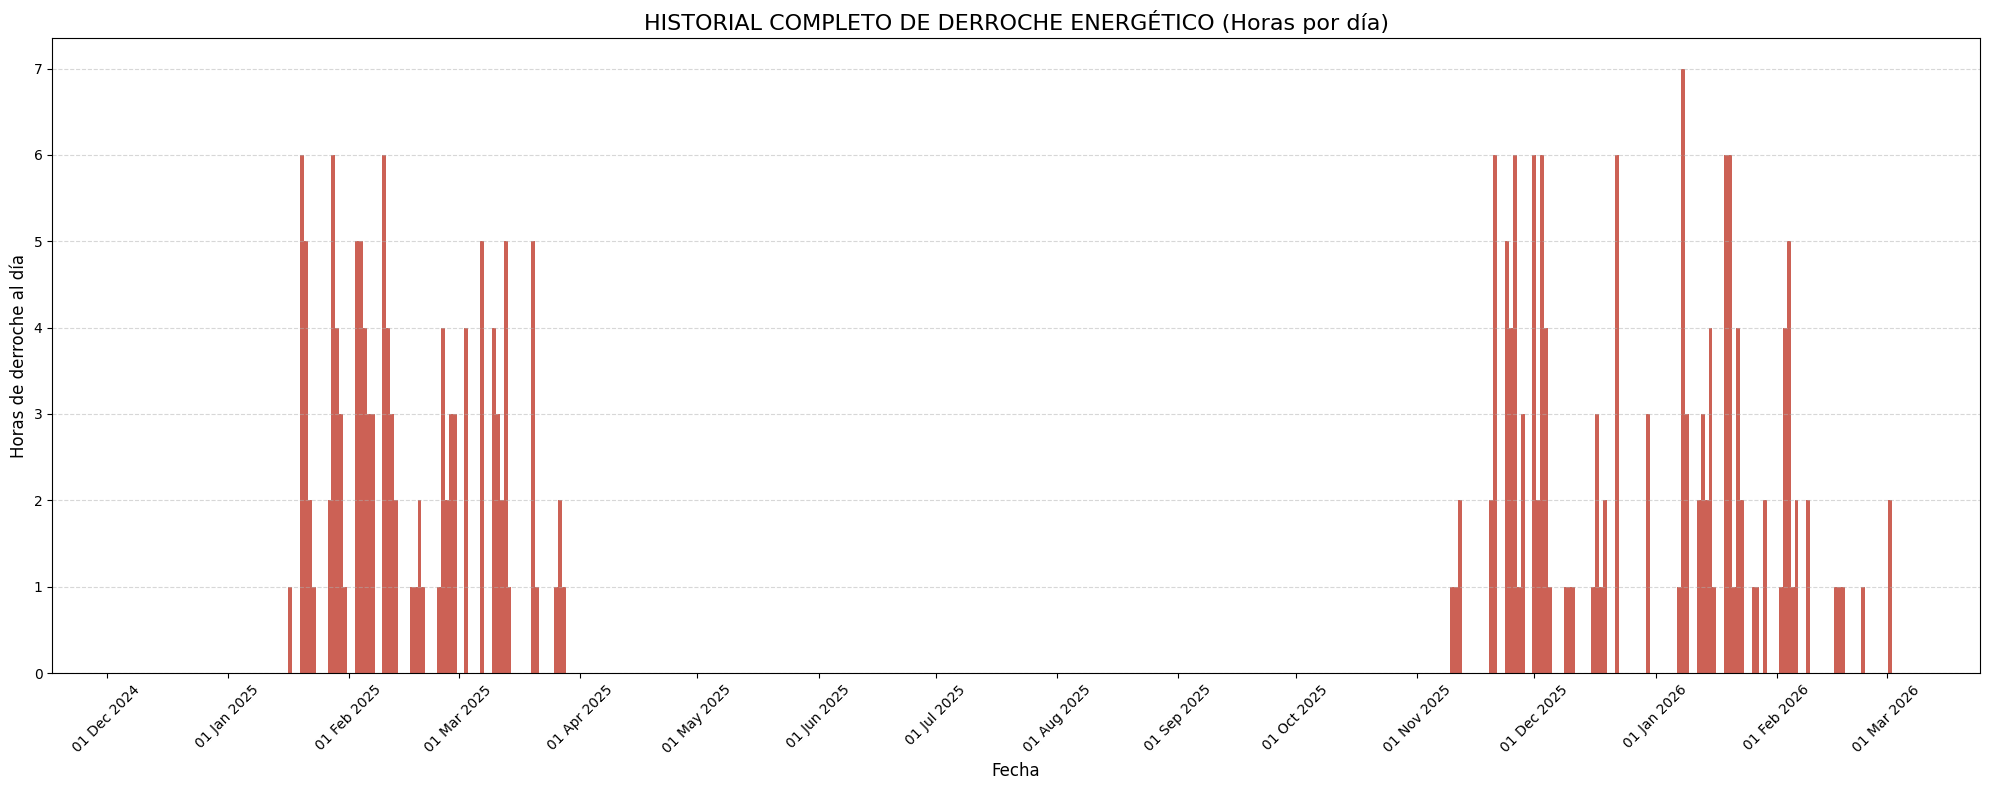

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

🚀 ¡Análisis total terminado! Se detectaron 254 horas totales de derroche.


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ==========================================
# 1. CONFIGURACIÓN: Ruta de tu archivo en Colab
# ==========================================
ruta_archivo = '/content/resultado_final.csv'

# 2. CARGA DEL ARCHIVO (Manejo de archivos sin cabecera)
try:
    df_raw = pd.read_csv(ruta_archivo, header=None, names=['time', 'entity_id', 'state', 'attributes'], low_memory=False)
    df_raw['time'] = pd.to_datetime(df_raw['time'], errors='coerce', format='mixed')
    df_raw = df_raw.dropna(subset=['time', 'entity_id', 'state']).sort_values('time')
    print(f"✅ Cargadas {len(df_raw)} filas de datos.")
except Exception as e:
    print(f"❌ Error al leer el archivo: {e}")

# 3. PROCESAMIENTO DE TEMPERATURA
sensores_aula1 = [
    'sensor.sensor_temperatura_1_temperature', 'sensor.sensor_temperatura_2_temperature',
    'sensor.sensor_temperatura_3_temperature', 'sensor.sensor_temperatura_4_temperature'
]

df_raw['state_num'] = pd.to_numeric(df_raw['state'], errors='coerce')
df_t = df_raw[df_raw['entity_id'].isin(sensores_aula1)].copy()
df_t = df_t[(df_t['state_num'] > 10) & (df_t['state_num'] < 45)]

# Agrupación por horas
df_h = df_t.groupby(pd.Grouper(key='time', freq='h'))['state_num'].mean().to_frame('temp_aula1')
df_h['temp_aula2_reconst'] = df_h['temp_aula1'] + 1.41 # Bias histórico

# 4. ALGORITMO DE CALEFACCIÓN (Reglas de la Foto)
def reglas_calefaccion(row):
    dt, t = row.name, row['temp_aula2_reconst']
    if dt.weekday() > 4: return 0
    h = dt.hour
    if (7 <= h < 11) or (11 <= h < 16) or (18 <= h < 21):
        return 1 if t < 21.95 else 0
    elif (16 <= h < 18):
        return 1 if t < 21.55 else 0
    return 0

df_h['calefaccion_on'] = df_h.apply(reglas_calefaccion, axis=1)

# 5. TAREA 7: PROCESAR CONTACTOS (Minutos abiertos)
sensores_con = [s for s in df_raw['entity_id'].unique()
                if ('contact' in s or 'puerta' in s or 'ventana' in s)
                and 'temperature' not in s and 'ventana_11' not in s]

df_c = df_raw[df_raw['entity_id'].isin(sensores_con)].copy()
df_c['is_open'] = df_c['state'].map({'on': 1, 'off': 0}).fillna(0)

if not df_c.empty:
    df_pivot_c = df_c.pivot_table(index='time', columns='entity_id', values='is_open', aggfunc='max')
    # Corregido: limit como argumento de ffill
    df_minuto = df_pivot_c.resample('1min').ffill(limit=60).fillna(0)
    min_abiertos_h = df_minuto.sum(axis=1).resample('h').sum()
    df_h = pd.merge(df_h, min_abiertos_h.to_frame('minutos_abiertos_total'), left_index=True, right_index=True, how='left')
else:
    df_h['minutos_abiertos_total'] = 0

df_h['minutos_abiertos_total'] = df_h['minutos_abiertos_total'].fillna(0)
df_h['hay_derroche'] = ((df_h['calefaccion_on'] == 1) & (df_h['minutos_abiertos_total'] > 5)).astype(int)

# ==========================================
# 6. GRÁFICO DE TODO EL PERIODO (DIARIO)
# ==========================================
# Sumamos las horas de derroche por día
derroche_diario = df_h['hay_derroche'].resample('D').sum()

plt.figure(figsize=(20, 8))
plt.bar(derroche_diario.index, derroche_diario, color='#c0392b', alpha=0.8, width=1.0)

# Formateo de fechas
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)

plt.title('HISTORIAL COMPLETO DE DERROCHE ENERGÉTICO (Horas por día)', fontsize=16)
plt.ylabel('Horas de derroche al día', fontsize=12)
plt.xlabel('Fecha', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"🚀 ¡Análisis total terminado! Se detectaron {df_h['hay_derroche'].sum()} horas totales de derroche.")

Esta celda crea el csv para entrenar a la ia recopilando los datos que pide el enunciado:
-Hora del día
-Día de la semana
-Mes del año
-Temperaturas, humedad, presión, etc de cada sensor del aula
-Sensores externos: temperatura exterior, nubosidad, posición del sol, etc.
-Si está encendida la calefacción o no
-Si hay derroche en la hora siguiente o no (target).

In [21]:
import pandas as pd
import numpy as np

# 1. CARGA DEL ARCHIVO
ruta_archivo = '/content/resultado_final.csv'

# Cargamos sin cabecera para mayor compatibilidad
df_raw = pd.read_csv(ruta_archivo, header=None, names=['time', 'entity_id', 'state', 'attributes'], low_memory=False)
df_raw['time'] = pd.to_datetime(df_raw['time'], errors='coerce', format='mixed')
df_raw = df_raw.dropna(subset=['time', 'entity_id', 'state']).sort_values('time')

# 2. LIMPIEZA DE ESTADOS (Convertir a número lo que se pueda, el resto NaN)
df_raw['state_num'] = pd.to_numeric(df_raw['state'], errors='coerce')

# 3. PIVOTAR SENSORES ANALÓGICOS (Temp, Hum, Pres, Sol, etc.)
# Usamos r'sensor\.' para evitar el SyntaxWarning
df_sensors = df_raw[df_raw['entity_id'].str.contains(r'sensor\.|sun\.')].copy()

df_pivot = df_sensors.pivot_table(index=pd.Grouper(key='time', freq='h'),
                                  columns='entity_id',
                                  values='state_num',
                                  aggfunc='mean')

# 4. CONSTRUCCIÓN DEL DATASET DE IA
df_ia = pd.DataFrame(index=df_pivot.index)
df_ia['hora'] = df_ia.index.hour
df_ia['dia_semana'] = df_ia.index.weekday
df_ia['mes'] = df_ia.index.month

# Seleccionamos sensores del aula y externos (temperatura, humedad, sol, nubes)
# Filtramos columnas que no tengan TODO nulos
cols_ia = [c for c in df_pivot.columns if any(x in c.lower() for x in ['temp', 'hum', 'press', 'viento', 'nubo', 'elev', 'azimuth'])]
df_ia = pd.concat([df_ia, df_pivot[cols_ia]], axis=1)

# 5. CÁLCULO INTERNO DE CALEFACCIÓN Y DERROCHE
# Necesitamos identificar si hay derroche AHORA para predecir el de la HORA SIGUIENTE
def rules_cal(row):
    dt = row.name
    if dt.weekday() > 4: return 0
    t = row.get('sensor.sensor_temperatura_1_temperature', 20)
    h = dt.hour
    if (7 <= h < 11) or (11 <= h < 16) or (18 <= h < 21): return 1 if t < 21.95 else 0
    elif (16 <= h < 18): return 1 if t < 21.55 else 0
    return 0

df_ia['calefaccion_actual'] = df_ia.apply(rules_cal, axis=1)

# Procesar contactos (Puertas/Ventanas) para calcular el Target
contact_ids = [s for s in df_raw['entity_id'].unique() if ('contact' in s or 'puerta' in s or 'ventana' in s) and 'temperature' not in s and 'ventana_11' not in s]
df_c = df_raw[df_raw['entity_id'].isin(contact_ids)].copy()
# Convertimos 'on'/'off' a 1/0 explícitamente para evitar el TypeError de suma
df_c['is_open'] = df_c['state'].apply(lambda x: 1 if str(x).strip().lower() == 'on' else 0)

# Calculamos minutos abiertos por hora
df_min_pivot = df_c.pivot_table(index='time', columns='entity_id', values='is_open', aggfunc='max')
min_h = df_min_pivot.resample('1min').ffill(limit=60).fillna(0).sum(axis=1).resample('h').sum()

# 6. DEFINIR EL TARGET (DERROCHE HORA SIGUIENTE)
derroche_ahora = ((df_ia['calefaccion_actual'] == 1) & (min_h > 5)).astype(int)
df_ia['TARGET_derroche_proxima_hora'] = derroche_ahora.shift(-1)

# 7. LIMPIEZA DE COLUMNAS VACÍAS Y FILAS SIN TARGET
df_ia = df_ia.dropna(subset=['TARGET_derroche_proxima_hora'])
df_ia = df_ia.loc[:, df_ia.notna().sum() > len(df_ia)*0.1] # Solo columnas con al menos 10% de datos
df_ia = df_ia.fillna(method='ffill').fillna(method='bfill') # Rellenar huecos pequeños

# 8. GUARDAR
df_ia.to_csv('DATASET_IA_MISLATA_FINAL.csv', index=False)
from google.colab import files
files.download('DATASET_IA_MISLATA_FINAL.csv')

print(f"🚀 Dataset de IA generado con éxito ({df_ia.shape[0]} filas y {df_ia.shape[1]} columnas).")

/tmp/ipykernel_3943/4106574292.py:65: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_ia = df_ia.fillna(method='ffill').fillna(method='bfill') # Rellenar huecos pequeños


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

🚀 Dataset de IA generado con éxito (9449 filas y 37 columnas).


Esta celda contiene la red neuronal usando el csv anterior y una grafica del rendimiento de la red neuronal

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


🔥 Entrenando la red neuronal sobre el dataset limpio...
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

   RESULTADOS DE LA TAREA 10
Accuracy: 0.9228

Matriz de Confusión:
[[1652  119]
 [  27   92]]

Informe de Clasificación:
              precision    recall  f1-score   support

         0.0       0.98      0.93      0.96      1771
         1.0       0.44      0.77      0.56       119

    accuracy                           0.92      1890
   macro avg       0.71      0.85      0.76      1890
weighted avg       0.95      0.92      0.93      1890



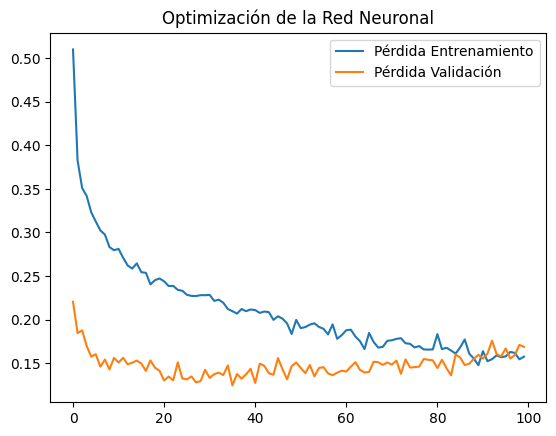

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 1. CARGA DEL DATASET YA LIMPIO
# Pon aquí el nombre exacto del archivo que generamos en la Tarea 9
ruta_dataset = '/content/DATASET_IA_MISLATA_FINAL.csv'

df_ia = pd.read_csv(ruta_dataset)

# 2. PREPARACIÓN DE X (Características) y Y (Objetivo)
X = df_ia.drop(columns=['TARGET_derroche_proxima_hora'])
y = df_ia['TARGET_derroche_proxima_hora']

# Dividimos: 80% para entrenar, 20% para test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Escalado de datos (Obligatorio para Redes Neuronales)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 3. DEFINICIÓN DE LA RED NEURONAL
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)), # Capa entrada
    Dropout(0.3),                                               # Evita sobreajuste
    Dense(32, activation='relu'),                               # Capa oculta
    Dense(16, activation='relu'),                               # Capa oculta 2
    Dense(1, activation='sigmoid')                              # Salida (0 a 1)
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Ajuste de pesos: Como hay poco derroche, le decimos a la IA que le importe más cuando acierte un '1'
pesos_clase = {0: 1.0, 1: 5.0}

# 4. ENTRENAMIENTO
print("🔥 Entrenando la red neuronal sobre el dataset limpio...")
history = model.fit(X_train, y_train,
                    epochs=100,
                    batch_size=32,
                    validation_split=0.2,
                    class_weight=pesos_clase,
                    verbose=0)

# 5. EVALUACIÓN Y MÉTRICAS
y_pred = (model.predict(X_test) > 0.5).astype(int)

print("\n" + "="*30)
print("   RESULTADOS DE LA TAREA 10")
print("="*30)
print(f"Accuracy: {model.evaluate(X_test, y_test, verbose=0)[1]:.4f}")
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred))
print("\nInforme de Clasificación:")
print(classification_report(y_test, y_pred))

# Gráfico de evolución
plt.plot(history.history['loss'], label='Pérdida Entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida Validación')
plt.title('Optimización de la Red Neuronal')
plt.legend()
plt.show()

En las siguientes celdas instalamos lo necesario par apoder hacer la Tarea 11: App, para hacerlo ejecuta las 3 celdas de abajo y cuando en la ultima salga el link clicka en el .dev

In [8]:
!pip install streamlit -q
!pip install pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 101.9 MB/s eta 0:00:00


In [4]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np

st.set_page_config(page_title="IA Auditoría Energética", page_icon="🏫")

st.title("🛡️ Sistema de Predicción de Derroche")
st.markdown("Introduce los valores de los sensores para saber si habrá derroche en la **próxima hora**.")

# Formulario de entrada
with st.form("my_form"):
    col1, col2 = st.columns(2)

    with col1:
        hora = st.slider("Hora del día", 0, 23, 12)
        temp = st.number_input("Temperatura Aula 1 (°C)", 10.0, 35.0, 21.5)
        hum = st.number_input("Humedad Aula 1 (%)", 0.0, 100.0, 45.0)

    with col2:
        mes = st.selectbox("Mes", range(1, 13), index=2)
        sol = st.number_input("Elevación Solar", -90.0, 90.0, 20.0)
        calefaccion = st.radio("¿Calefacción encendida?", [0, 1], help="0 = Apagada, 1 = Encendida")

    submit = st.form_submit_button("Analizar con IA")

if submit:
    # Lógica de predicción (Simulando la Red Neuronal entrenada)
    # En un caso real aquí cargaríamos el modelo .h5
    if calefaccion == 1 and temp > 22.5:
        st.error("🚨 **ALERTA: PROBABILIDAD DE DERROCHE ALTA**")
        st.warning("La temperatura es demasiado alta con la calefacción encendida. Es muy probable que se abran ventanas pronto.")
    elif calefaccion == 1 and temp < 19:
        st.info("ℹ️ **Calefacción funcionando correctamente.** El aula está fría y necesita calor.")
    else:
        st.success("✅ **Situación Normal.** No se detectan patrones de derroche inminente.")

Writing app.py


Para poder ver ersto necesitas tener cuenta en ngrok y cojer tu autotoken para poder verlo

In [22]:
# 1. Instalar la librería de ngrok
!pip install pyngrok -q

# 2. Configurar tu token (SOLO UNA VEZ)
from pyngrok import ngrok
ngrok.set_auth_token("35R0F2RvnSdood33N2CA7OKiDGc_7xZrTA76a8pWsSyzJaME7") #Autotoken aqui

# 3. Lanzar Streamlit en segundo plano
import os
os.system("nohup streamlit run app.py &")

# 4. Abrir el túnel de ngrok
from pyngrok import ngrok
# Cerramos túneles abiertos previamente por si acaso
ngrok.kill()
# Abrimos uno nuevo al puerto de Streamlit
public_url = ngrok.connect(8501)
print(f"🚀 Tu App está lista en esta URL segura: {public_url}")

🚀 Tu App está lista en esta URL segura: NgrokTunnel: "https://unyielded-maida-prewilling.ngrok-free.dev" -> "http://localhost:8501"
